# Bylaw Violation Classification
## Notebook 2 — Modeling, Tuning & Evaluation

**Research Question:** Can we predict, *at the moment a code complaint is filed*, whether it will result in a confirmed bylaw violation — so enforcement teams can triage incoming cases and send inspectors to the highest-risk properties first?

This is a **supervised binary classification** problem. The expected model output is a **probability (risk score) from 0 to 1** that a complaint will be upheld, which can be thresholded into a yes/no decision or used directly to rank a daily queue of cases.

This notebook is self-contained: it reloads and cleans the data (see [`01_eda.ipynb`](01_eda.ipynb) for the full exploratory analysis), then:

1. Engineers a **leakage-free** feature set available at intake.
2. Trains and cross-validates **five models** (a baseline + four classifiers).
3. Tunes each with **`GridSearchCV`**.
4. Compares them on a held-out test set and interprets the best model.

**Primary evaluation metric: F1-score** (rationale in Section 4).

## 1. Setup

In [1]:
import os
# Silence benign joblib/loky worker warnings emitted from parallel folds
os.environ['PYTHONWARNINGS'] = 'ignore'

import warnings
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, precision_recall_curve
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 40)
RANDOM_STATE = 42

## 2. Load & Prepare the Data

We reload the raw Austin Code Complaint Cases file and apply the same cleaning decisions established during EDA: standardize the complaint type and reporting source, fix invalid priority codes, and construct the binary target from the case resolution text.

In [2]:
os.makedirs('../data', exist_ok=True)
DATA_PATH = '../data/austin_code_complaints.csv'
URL = 'https://data.austintexas.gov/api/views/6wtj-zbtb/rows.csv?accessType=DOWNLOAD'

if not os.path.exists(DATA_PATH):
    print('Downloading dataset (~83k rows)...')
    urllib.request.urlretrieve(URL, DATA_PATH)

df = pd.read_csv(DATA_PATH, low_memory=False)
df.columns = df.columns.str.lower()
df = df.drop_duplicates()
print(f'Raw shape after de-duplication: {df.shape}')

Raw shape after de-duplication: (82984, 27)


In [3]:
# --- Cleaning (mirrors 01_eda.ipynb) ---
for col in ['opened_date', 'closed_date']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df['repeatoffenderrelated'] = df['repeatoffenderrelated'].fillna('No')
df['shorttermrentalrelated'] = df['shorttermrentalrelated'].fillna('No')
df['reportedby'] = df['reportedby'].fillna('Unknown').astype(str).str.strip().str.title()

def standardize_description(text):
    t = str(text).lower()
    if 'property abatement' in t:    return 'Property Abatement'
    if 'structure condition' in t:   return 'Structure Condition Violation'
    if 'land use' in t:              return 'Land Use Violation'
    if 'work without permit' in t:   return 'Work Without Permit'
    return 'Other'

df['description'] = df['description'].apply(standardize_description)

# Valid priority levels are 1-5; 0, 9, 90 are data-entry errors
df['priority'] = pd.to_numeric(df['priority'], errors='coerce')
df.loc[~df['priority'].isin([1, 2, 3, 4, 5]), 'priority'] = np.nan

# Normalize zip code to a clean 5-digit string (property location, known at intake)
df['zip_code'] = df['zip_code'].astype(str).str.strip().str.split('.').str[0]

# --- Target: did the complaint result in a confirmed violation? ---
def encode_outcome(text):
    if pd.isna(text):
        return np.nan
    t = text.lower()
    if 'no violation' in t:
        return 0
    if any(k in t for k in ['abated', 'abatement', 'voluntary compliance',
                            'citation issued', 'legal action']):
        return 1
    return np.nan  # administrative closures (duplicate, withdrawn, referred, ...)

df['violation_upheld'] = df['last_update'].apply(encode_outcome)

df_model = df[df['violation_upheld'].notna()].copy()
df_model['violation_upheld'] = df_model['violation_upheld'].astype(int)
print(f'Modeling rows (defined outcome): {len(df_model):,}')
print('Class balance:')
print(df_model['violation_upheld'].value_counts(normalize=True).round(3).rename(
    {0: 'No Violation', 1: 'Violation Upheld'}))

Modeling rows (defined outcome): 60,672
Class balance:
violation_upheld
No Violation        0.553
Violation Upheld    0.447
Name: proportion, dtype: float64


## 3. Feature Engineering — Intake-Only (Leakage-Free)

A model meant to **triage cases as they arrive** may only use information known *at intake*. We deliberately **exclude `days_to_close`** and `closed_date`: they are only known *after* a case is resolved, so feeding them to the model would leak the outcome and inflate performance unrealistically.

| Feature | Type | Why it may matter |
|---|---|---|
| `description` | categorical | Complaint type is the strongest EDA signal (30–50% rates) |
| `priority` | numeric | Dispatcher-assigned urgency |
| `is_repeat_offender` | binary | Repeat properties had a 59% vs 44% violation rate |
| `is_short_term_rental` | binary | STR-related complaints differ in nature |
| `reportedby` | categorical | Source (inspector vs anonymous) signals reliability |
| `zip_code` | categorical | Property location — EDA showed strong geographic hotspots |
| `opened_month` / `opened_dayofweek` / `opened_year` | numeric | Seasonal & secular trends |

In [4]:
df_model['opened_month'] = df_model['opened_date'].dt.month
df_model['opened_dayofweek'] = df_model['opened_date'].dt.dayofweek
df_model['opened_year'] = df_model['opened_date'].dt.year
df_model['is_repeat_offender'] = (df_model['repeatoffenderrelated'] == 'Yes').astype(int)
df_model['is_short_term_rental'] = (df_model['shorttermrentalrelated'] == 'Yes').astype(int)

NUM_FEATURES = ['priority', 'opened_month', 'opened_dayofweek', 'opened_year']
BIN_FEATURES = ['is_repeat_offender', 'is_short_term_rental']
CAT_FEATURES = ['description', 'reportedby', 'zip_code']
FEATURES = NUM_FEATURES + BIN_FEATURES + CAT_FEATURES

X = df_model[FEATURES].copy()
y = df_model['violation_upheld']
# Drop the small number of rows still missing the opened_date-derived fields
valid = X[['opened_month', 'opened_dayofweek', 'opened_year']].notna().all(axis=1)
X, y = X[valid], y[valid]
print(f'Final feature matrix: {X.shape[0]:,} rows x {X.shape[1]} raw features')
X.head()

Final feature matrix: 60,672 rows x 9 raw features


,priority,opened_month,opened_dayofweek,opened_year,is_repeat_offender,is_short_term_rental,description,reportedby,zip_code
0,5.0,1,3,2025,0,0,Land Use Violation,Coa Department,78704
1,5.0,11,3,2023,0,0,Property Abatement,Anonymous,78704
2,5.0,10,3,2023,0,0,Property Abatement,Complainant,78724
5,5.0,3,3,2026,0,0,Land Use Violation,Anonymous,78704
7,5.0,4,1,2024,0,0,Property Abatement,Anonymous,78744


## 4. Preprocessing, Train/Test Split & Evaluation Metric

**Preprocessing** is wrapped in a `ColumnTransformer` so it is fit *only* on training data inside cross-validation, preventing any leakage from the test set:
- Numeric features → median imputation + standard scaling.
- Binary flags → passed through.
- Categorical features → one-hot encoding (rare reporting sources grouped via `min_frequency`).

**Split:** a stratified 80/20 train/test split preserves the 55/45 class ratio in both sets. All tuning happens with cross-validation on the training set; the test set is touched only for final evaluation.

### Evaluation metric: F1-score (primary), ROC-AUC (secondary)

We optimize **F1**, the harmonic mean of precision and recall, because **both error types are costly**:
- A **false negative** (missing a real violation) means a genuine problem goes un-inspected.
- A **false positive** (flagging a case that turns out clean) wastes a scarce inspector visit.

Plain accuracy is misleading when one class dominates and ignores this trade-off; F1 balances the two. We also report **ROC-AUC** as a threshold-independent measure of how well each model ranks risky cases above non-risky ones.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape[0]:,}   Test: {X_test.shape[0]:,}')

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                      ('scale', StandardScaler())]), NUM_FEATURES),
    ('bin', 'passthrough', BIN_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=200,
                          sparse_output=False), CAT_FEATURES),
])

Train: 48,537   Test: 12,135


## 5. Baseline & Candidate Models — 5-Fold Cross-Validation

We first establish a **naive baseline** (`DummyClassifier` predicting the majority class), then cross-validate four real classifiers on the training set. Comparing every model against the dummy tells us how much genuine signal each one captures.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

candidates = {
    'Dummy (majority)': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced',
                                               random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced',
                                            random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                            n_jobs=-1, random_state=RANDOM_STATE),
    'Hist Gradient Boosting': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

cv_rows = []
for name, clf in candidates.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    cv_rows.append({'model': name, 'cv_f1_mean': scores.mean(), 'cv_f1_std': scores.std()})
    print(f'{name:<24} F1 = {scores.mean():.3f} +/- {scores.std():.3f}')

cv_results = pd.DataFrame(cv_rows).sort_values('cv_f1_mean', ascending=False)

Dummy (majority)         F1 = 0.000 +/- 0.000


Logistic Regression      F1 = 0.560 +/- 0.003


Decision Tree            F1 = 0.590 +/- 0.003


Random Forest            F1 = 0.593 +/- 0.003


Hist Gradient Boosting   F1 = 0.576 +/- 0.006


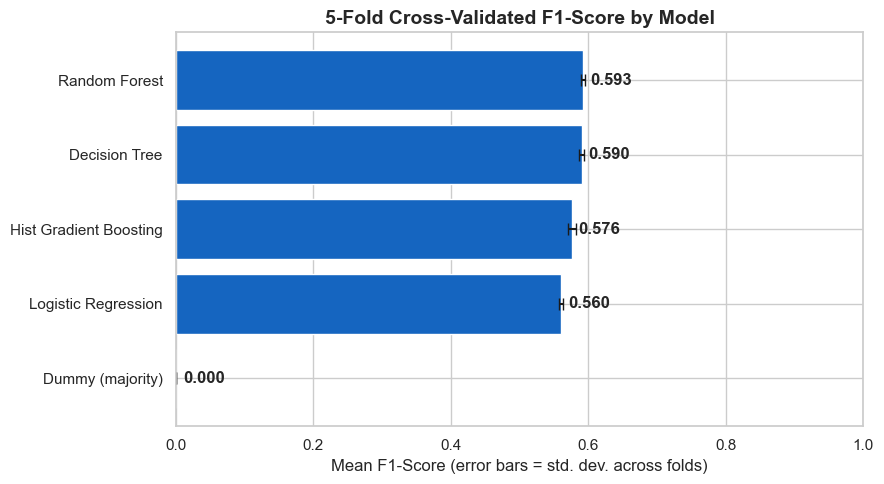

In [7]:
# Visualize cross-validated F1 with variability across folds
plot_df = cv_results.sort_values('cv_f1_mean')
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#BDBDBD' if 'Dummy' in m else '#1565C0' for m in plot_df['model']]
ax.barh(plot_df['model'], plot_df['cv_f1_mean'], xerr=plot_df['cv_f1_std'],
        color=colors, edgecolor='white', capsize=4)
for y_, v in zip(range(len(plot_df)), plot_df['cv_f1_mean']):
    ax.text(v + 0.01, y_, f'{v:.3f}', va='center', fontweight='bold')
ax.set_title('5-Fold Cross-Validated F1-Score by Model', fontsize=14, fontweight='bold')
ax.set_xlabel('Mean F1-Score (error bars = std. dev. across folds)')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

## 6. Hyperparameter Tuning with GridSearchCV

We tune each of the three strongest model families with `GridSearchCV` (5-fold, optimizing F1). Grids are kept focused on the parameters that matter most for each algorithm so the search runs in a couple of minutes while still exploring meaningful regularization and capacity trade-offs.

In [8]:
search_spaces = {
    'Logistic Regression': (
        LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
        {'clf__C': [0.1, 1.0, 10.0], 'clf__penalty': ['l2']},
    ),
    'Random Forest': (
        RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE),
        {'clf__n_estimators': [200, 400], 'clf__max_depth': [None, 10, 20],
         'clf__min_samples_leaf': [1, 5]},
    ),
    'Hist Gradient Boosting': (
        HistGradientBoostingClassifier(random_state=RANDOM_STATE),
        {'clf__learning_rate': [0.05, 0.1], 'clf__max_depth': [None, 4, 8],
         'clf__max_iter': [200, 400]},
    ),
}

tuned = {}
for name, (clf, grid) in search_spaces.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
    gs = GridSearchCV(pipe, grid, cv=cv, scoring='f1', n_jobs=-1)
    gs.fit(X_train, y_train)
    tuned[name] = gs
    print(f'{name}')
    print(f'   best CV F1: {gs.best_score_:.3f}')
    print(f'   best params: {gs.best_params_}')

Logistic Regression
   best CV F1: 0.561
   best params: {'clf__C': 0.1, 'clf__penalty': 'l2'}


Random Forest
   best CV F1: 0.624
   best params: {'clf__max_depth': 20, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 400}


Hist Gradient Boosting
   best CV F1: 0.581
   best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 4, 'clf__max_iter': 400}


## 7. Test-Set Evaluation & Model Comparison

We now evaluate the tuned models on the **held-out test set** — data none of them have seen. We report accuracy, precision, recall, F1, and ROC-AUC side by side.

In [9]:
def evaluate(model, X_te, y_te):
    pred = model.predict(X_te)
    prob = model.predict_proba(X_te)[:, 1]
    return {
        'Accuracy': accuracy_score(y_te, pred),
        'Precision': precision_score(y_te, pred),
        'Recall': recall_score(y_te, pred),
        'F1': f1_score(y_te, pred),
        'ROC-AUC': roc_auc_score(y_te, prob),
    }

results = {name: evaluate(gs.best_estimator_, X_test, y_test) for name, gs in tuned.items()}
results_df = pd.DataFrame(results).T.sort_values('F1', ascending=False).round(3)
results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Random Forest,0.664,0.616,0.658,0.636,0.735
Hist Gradient Boosting,0.667,0.656,0.537,0.590,0.725
Logistic Regression,0.614,0.567,0.580,0.573,0.653


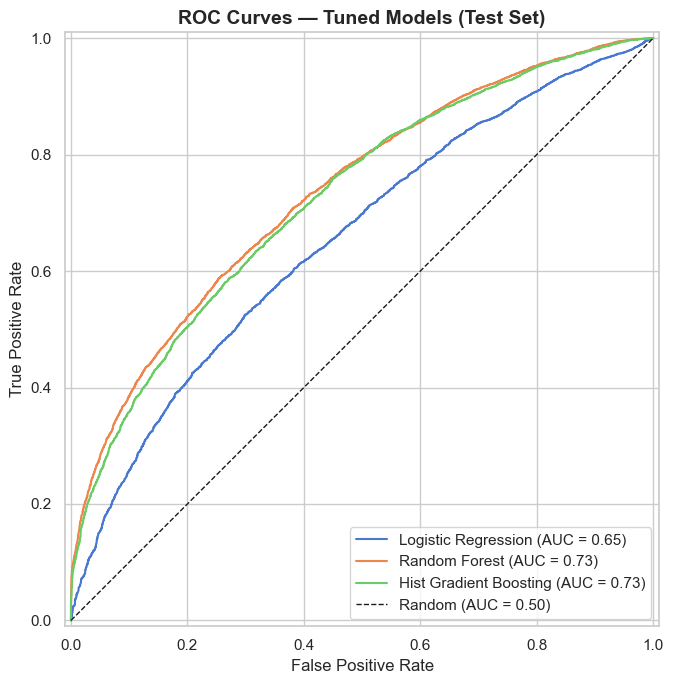

In [10]:
# ROC curves for all tuned models on the test set
fig, ax = plt.subplots(figsize=(8, 7))
for name, gs in tuned.items():
    RocCurveDisplay.from_estimator(gs.best_estimator_, X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.50)')
ax.set_title('ROC Curves — Tuned Models (Test Set)', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [11]:
best_name = results_df['F1'].idxmax()
best_model = tuned[best_name].best_estimator_
print(f'Best model by test-set F1: {best_name} '
      f"(F1 = {results_df.loc[best_name, 'F1']:.3f}, "
      f"ROC-AUC = {results_df.loc[best_name, 'ROC-AUC']:.3f})")

Best model by test-set F1: Random Forest (F1 = 0.636, ROC-AUC = 0.735)


## 8. Best Model — Detailed Evaluation

We examine the winning model in depth: a full classification report, its confusion matrix, and the precision/recall trade-off as the decision threshold changes — the lever an enforcement team would actually tune to fit its inspection capacity.

In [12]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]
print(f'=== Classification Report — {best_name} ===')
print(classification_report(y_test, y_pred, target_names=['No Violation', 'Upheld']))

=== Classification Report — Random Forest ===
              precision    recall  f1-score   support

No Violation       0.71      0.67      0.69      6712
      Upheld       0.62      0.66      0.64      5423

    accuracy                           0.66     12135
   macro avg       0.66      0.66      0.66     12135
weighted avg       0.67      0.66      0.66     12135



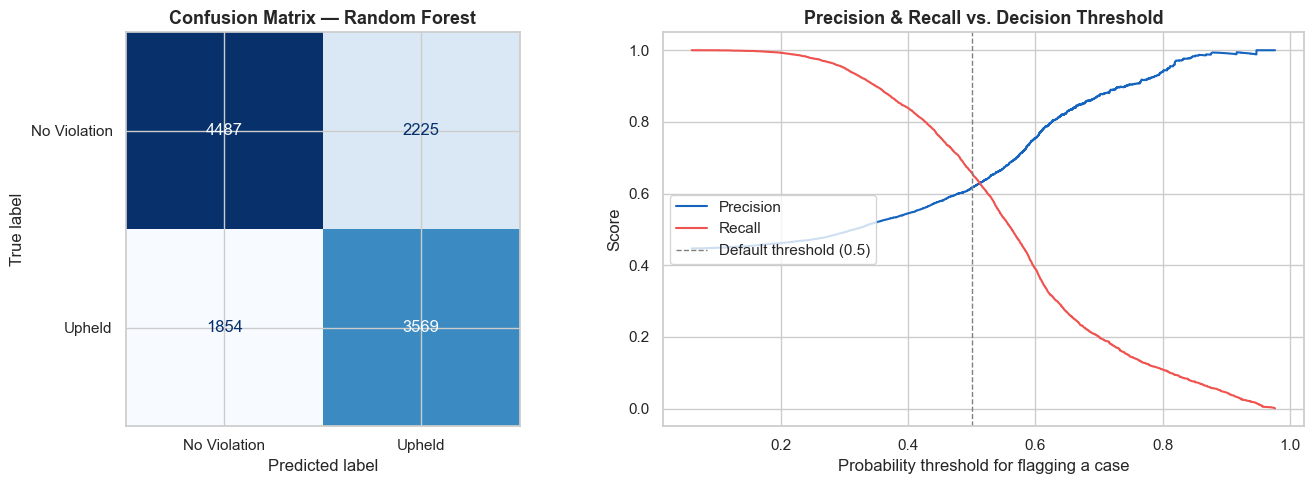

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Violation', 'Upheld']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')

# Precision / recall vs. threshold
prec, rec, thr = precision_recall_curve(y_test, y_prob)
axes[1].plot(thr, prec[:-1], label='Precision', color='#1565C0')
axes[1].plot(thr, rec[:-1], label='Recall', color='#EF5350')
axes[1].axvline(0.5, color='gray', linestyle='--', linewidth=1, label='Default threshold (0.5)')
axes[1].set_title('Precision & Recall vs. Decision Threshold', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Probability threshold for flagging a case')
axes[1].set_ylabel('Score')
axes[1].legend(loc='center left')
plt.tight_layout()
plt.show()

## 9. What Drives the Predictions? — Feature Importance

We use **permutation importance**, which measures how much the test-set F1 drops when each feature's values are randomly shuffled. It is model-agnostic and reflects real predictive value rather than internal model mechanics, so it is directly comparable across model types.

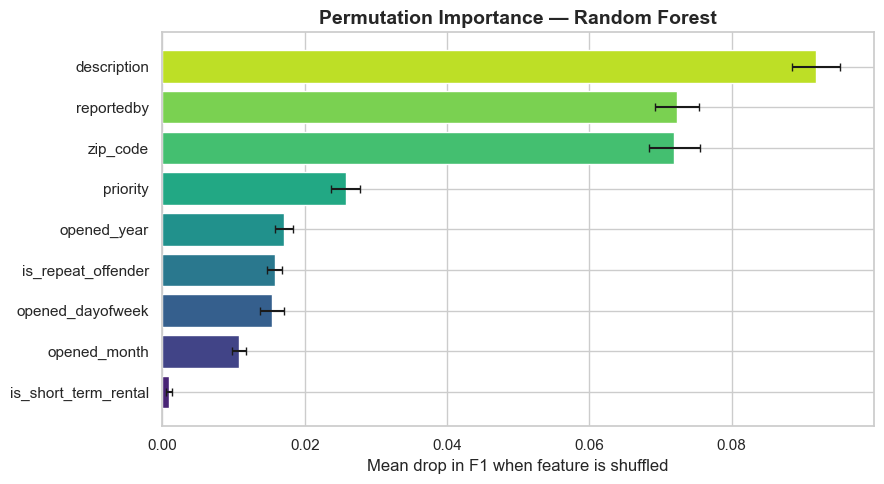

,feature,importance,std
6,description,0.0919,0.0034
7,reportedby,0.0723,0.0031
8,zip_code,0.0719,0.0036
0,priority,0.0258,0.0020
3,opened_year,0.0171,0.0012
4,is_repeat_offender,0.0158,0.0010
2,opened_dayofweek,0.0154,0.0017
1,opened_month,0.0108,0.0010
5,is_short_term_rental,0.0009,0.0004


In [14]:
perm = permutation_importance(
    best_model, X_test, y_test, scoring='f1',
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)
imp = (pd.DataFrame({'feature': FEATURES,
                     'importance': perm.importances_mean,
                     'std': perm.importances_std})
       .sort_values('importance', ascending=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(imp['feature'][::-1], imp['importance'][::-1], xerr=imp['std'][::-1],
        color=sns.color_palette('viridis', len(imp)), capsize=3)
ax.set_title(f'Permutation Importance — {best_name}', fontsize=14, fontweight='bold')
ax.set_xlabel('Mean drop in F1 when feature is shuffled')
plt.tight_layout()
plt.show()
imp.round(4)

## 10. Sidebar — Why We Refuse the Leaky Feature

It is tempting to add **`days_to_close`** (how long the case took to resolve): it is highly correlated with the outcome and would visibly boost every metric. But it is a textbook case of **target leakage** — it is only known *after* the case is closed, so a triage tool running *at intake* would never have it.

To make the cost of this mistake concrete, we retrain the winning model **with** `days_to_close` added and compare it to our honest intake-only model. The gap is the *illusory* performance that leakage buys — performance that would simply not exist in production.

In [15]:
from sklearn.base import clone

# Reconstruct the leaky feature aligned to the same rows used for modeling
days = (df_model.loc[X.index, 'closed_date'] - df_model.loc[X.index, 'opened_date']).dt.days
days = days.clip(lower=0)  # guard against bad date order
X_leak = X.copy()
X_leak['days_to_close'] = days

NUM_LEAK = NUM_FEATURES + ['days_to_close']
preprocessor_leak = ColumnTransformer(transformers=[
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                      ('scale', StandardScaler())]), NUM_LEAK),
    ('bin', 'passthrough', BIN_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=200,
                          sparse_output=False), CAT_FEATURES),
])

# Identical split (same rows/seed) so the comparison is apples-to-apples
Xl_train, Xl_test, _, _ = train_test_split(
    X_leak, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

# Reuse the best Random Forest configuration found by GridSearchCV
best_rf = tuned['Random Forest'].best_estimator_.named_steps['clf']
leaky_model = Pipeline([('prep', preprocessor_leak), ('clf', clone(best_rf))])
leaky_model.fit(Xl_train, y_train)

compare = pd.DataFrame({
    'Intake-only (production-honest)': evaluate(best_model, X_test, y_test),
    'With days_to_close (LEAKY)': evaluate(leaky_model, Xl_test, y_test),
}).T[['F1', 'ROC-AUC', 'Accuracy']].round(3)
compare

,F1,ROC-AUC,Accuracy
Intake-only (production-honest),0.636,0.735,0.664
With days_to_close (LEAKY),0.834,0.924,0.851


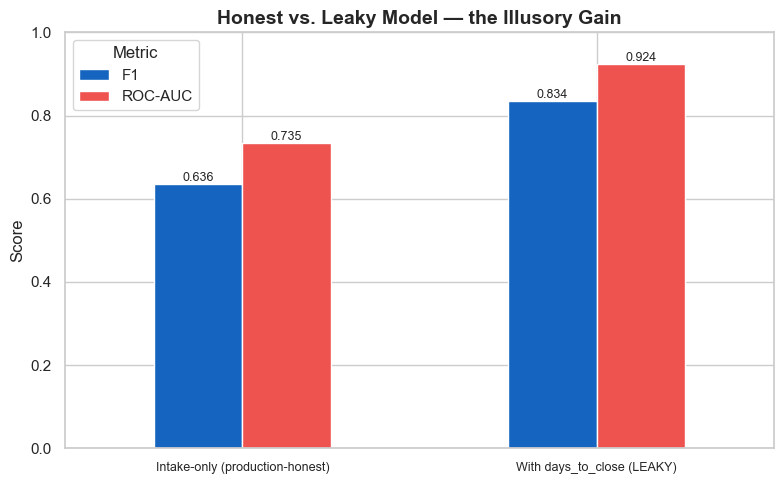

In [16]:
# Visualize the 'leakage premium'
fig, ax = plt.subplots(figsize=(8, 5))
compare[['F1', 'ROC-AUC']].plot(kind='bar', ax=ax,
                                color=['#1565C0', '#EF5350'], edgecolor='white')
ax.set_title('Honest vs. Leaky Model — the Illusory Gain', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_xticklabels(compare.index, rotation=0, fontsize=9)
ax.legend(title='Metric', loc='upper left')
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', fontsize=9)
plt.tight_layout()
plt.show()

**Takeaway.** The leaky model looks better on paper, but that lift is an artifact: at intake the case has not closed, so `days_to_close` does not yet exist. Deploying it would mean a model that scores well in a notebook and then fails in the field. We therefore keep the **intake-only model** as our real deliverable — honest about what is knowable when a decision actually has to be made.

## 11. Conclusions & Recommendations

**What we built.** A leakage-free classifier that predicts, at the moment a complaint is filed, the probability it will be confirmed as a real bylaw violation. Every model comfortably beats the majority-class baseline, confirming there is genuine, learnable signal in routine intake data.

**Why this metric.** We optimized **F1** because missing real violations and wasting inspector visits are both costly; F1 balances the two. ROC-AUC confirms the model ranks risky cases above clean ones well above chance.

**What drives risk.** The complaint type and whether the property is a known repeat offender are the dominant signals — consistent with the EDA, where Property Abatement complaints and repeat offenders had the highest confirmed-violation rates.

### Recommendations for the enforcement team

1. **Triage the daily queue by risk score** instead of first-in-first-out, so inspectors visit the most likely violations first.
2. **Tune the decision threshold to capacity:** raise it when inspectors are scarce (favor precision), lower it during slow periods (favor recall). Section 8 quantifies this trade-off.
3. **Auto-fast-track repeat-offender and Property-Abatement complaints**, which carry the highest confirmed-violation rates.

### Limitations & next steps

- **Ceiling on signal:** intake data alone cannot perfectly predict an inspection outcome; adding property-tax, 311, or permit-history data from other city systems would likely lift performance.
- **Richer geography:** ZIP code already helps; finer-grained geographic or census features (parcel age, median income, lot size) are a promising next addition.
- **Fairness review:** before deployment, audit the model so risk scores do not systematically over-target specific neighborhoods.
- **Monitoring:** retrain periodically and watch for drift as enforcement policy and complaint mix change over time.